In [43]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np

In [44]:
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

as_supervised:
Indica si el dataset se devuelve en formato supervisado. Cuando es True, los datos se cargan como pares (entrada, etiqueta), es decir (imagen, label), lo cual facilita el entrenamiento de modelos de aprendizaje supervisado.

with_info:
Indica si también se debe devolver la información del dataset. Cuando es True, la función retorna además un objeto con metadatos del dataset, como número de ejemplos, clases disponibles, descripción y divisiones de los datos.

In [45]:
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='C:\\Users\\angel\\tensorflow_datasets\\fashion_mnist\\3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP

In [46]:
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [47]:
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [48]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255
    return imagenes, etiquetas

In [49]:
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

map():
Se utiliza para aplicar una función a cada elemento de un conjunto de datos. En el caso de datasets de tensorFlow, permite transformar o preprocesar los datos, por ejemplo normalizar imágenes, cambiar su formato o modificar etiquetas antes de entrenar el modelo. es como un iterador, tambien existe en js

In [50]:
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

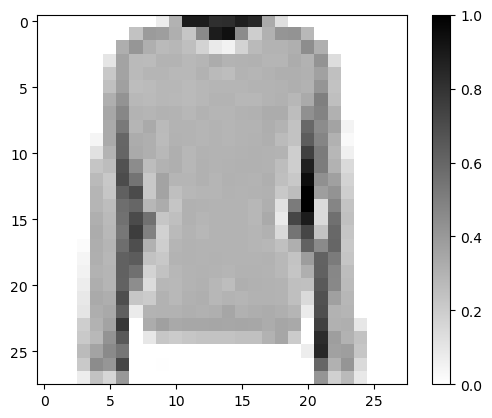

In [51]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break
imagen = imagen.numpy().reshape((28,28))

plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

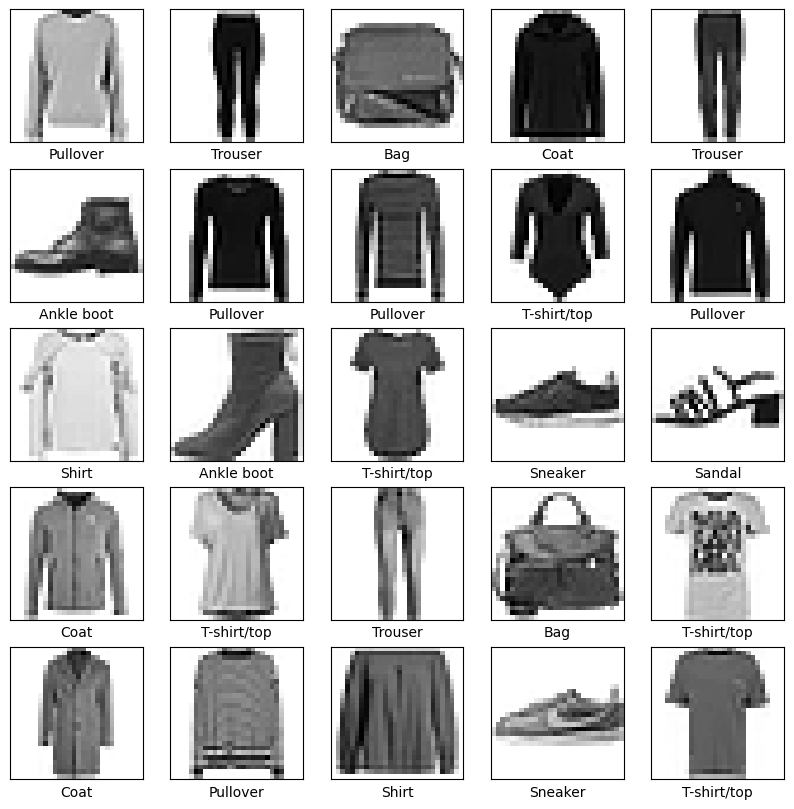

In [52]:
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28,28))
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
plt.show()

In [53]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

c:\Users\angel\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [55]:
TAMANO_LOTE = 32

In [56]:
num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples
print(num_ej_entrenamiento)
print(num_ej_pruebas)

60000
10000


In [57]:
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

In [58]:
historial = modelo.fit(datos_entrenamiento, epochs=28, steps_per_epoch=math.ceil(num_ej_entrenamiento/TAMANO_LOTE))

Epoch 1/28
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8167 - loss: 0.5227
Epoch 2/28
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8601 - loss: 0.3852
Epoch 3/28
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8710 - loss: 0.3540
Epoch 4/28
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8820 - loss: 0.3200
Epoch 5/28
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8857 - loss: 0.3086
Epoch 6/28
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8893 - loss: 0.3009
Epoch 7/28
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8933 - loss: 0.2863
Epoch 8/28
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8976 - loss: 0.2758
Epoch 9/28
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8990 - loss: 0.2699
Epoch 10/28
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9044 - loss: 0.2576
Epoch 11/28
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9044 - loss: 0.2526
Epoch 12/28
1875/1875 ━━━━━━━━

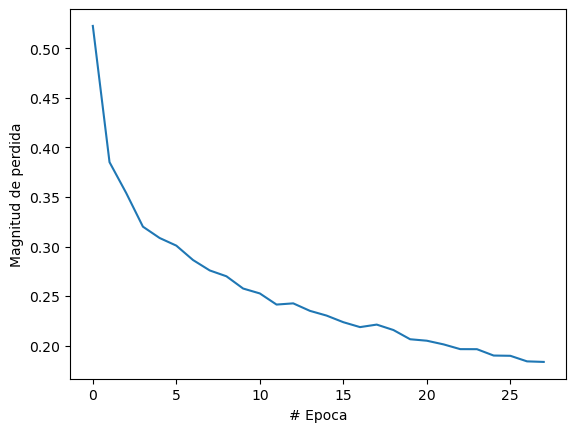

In [59]:
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de perdida")
plt.plot(historial.history["loss"])

In [60]:
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)
    if etiqueta_prediccion == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(
        nombres_clases[etiqueta_prediccion],
        100*np.max(arr_predicciones),
        nombres_clases[etiqueta_real]),
        color=color)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


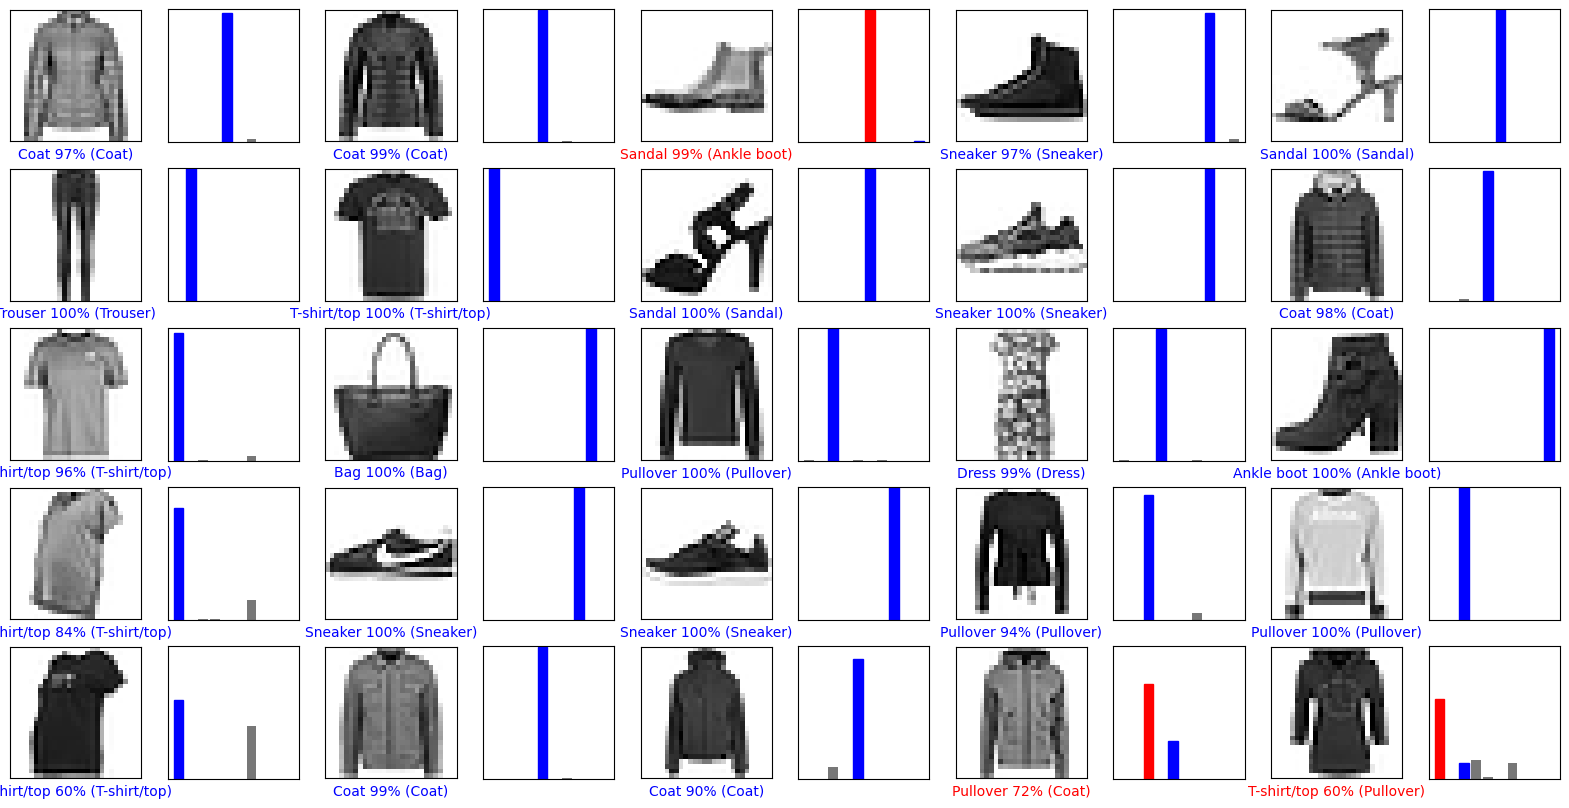

In [61]:
def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0, 1])
    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas * columnas
plt.figure(figsize=(2*2*columnas, 2*filas))

for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

In [62]:
imagen = imagenes_prueba[24]
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)

print("Prediccion: " + nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Prediccion: T-shirt/top


In [69]:
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import ipywidgets as widgets
from IPython.display import display, clear_output

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Cargar imagen'
)

salida = widgets.Output()

def preparar_imagen(contenido):
    img = Image.open(io.BytesIO(contenido)).convert('L')
    img = ImageOps.invert(img)
    img = img.resize((28, 28))
    img_array = np.array(img) / 255.0
    
    plt.figure(figsize=(3,3))
    plt.imshow(img_array, cmap='gray')
    plt.title("Imagen procesada 28x28")
    plt.axis('off')
    plt.show()
    
    return img_array.reshape(1, 28, 28, 1)

def cuando_cambia(change):
    with salida:
        clear_output()

        if len(uploader.value) == 0:
            return

        archivo = uploader.value[0]
        contenido = archivo['content']

        imagen_preparada = preparar_imagen(contenido)

        prediccion = modelo.predict(imagen_preparada)
        clase_predicha = np.argmax(prediccion)
        confianza = np.max(prediccion) * 100

        print(f"Clase predicha: {nombres_clases[clase_predicha]}")
        print(f"Confianza: {confianza:.2f}%")
        
        plt.figure(figsize=(8,3))
        plt.bar(range(len(nombres_clases)), prediccion[0])
        plt.xticks(range(len(nombres_clases)), nombres_clases, rotation=45)
        plt.title("Probabilidades por clase")
        plt.show()

uploader.observe(cuando_cambia, names='value')

display(uploader, salida)

FileUpload(value=(), accept='image/*', description='Cargar imagen')

Output()

El formato H5 (o HDF5, Hierarchical Data Format version 5) es un formato de archivo diseñado para almacenar grandes cantidades de datos de forma organizada y eficiente. Fue desarrollado por The HDF Group y es muy utilizado en ciencia, ingeniería y aprendizaje automático.
El formato H5 se utiliza principalmente para:
- Guardar grandes conjuntos de datos de manera eficiente.
- Almacenar modelos de aprendizaje automático, incluyendo su arquitectura, pesos y configuración.
- Organizar datos complejos en estructuras jerárquicas.
- Compartir datos científicos entre diferentes programas o plataformas.

In [70]:
modelo.save("act11.h5")